# Objective

Buscamos primero generar una matriz binaria que separa el suelo de las plantas, de manera que el análisis de bandas espectrales posteriores sea más preciso y no esté contaminado con los espectros del suelo.

La estrategia inicial busca aprovechar el cálculo de un índice de vegetación (Opción A):
1. Comencemos con un índice de 0.1 para separar lo que es la imagen real del fondo que no aporta nada.
2. Busquemos nuevamente un índice que ahora sí separa el suelo de las plantas

# Libraries

In [1]:
# Use this initial code to work in the notebook as if it were a module, that 
# is, to be able to export classes and functions from other subpackages.

import os
import sys

package_path = os.path.abspath('.').split(os.sep + 'notebooks')[0]
if package_path not in sys.path:
    sys.path.append(package_path)

%load_ext autoreload

In [2]:
import spectral
import numpy as np
import matplotlib.pyplot as plt

from spectra_bean.utils import PathManager

# Load image

Shape of hyperspectral data: (3660, 3438, 379)
Number of bands: 379
wavelegths: [411.03182, 413.93909, 416.84635, 419.75362, 422.66089, 425.56816, 428.47543, 431.38269, 434.28996, 437.19723, 440.1045, 443.01177, 445.91904, 448.8263, 451.73357, 454.64084, 457.54811, 460.45538, 463.36264, 466.26991, 469.17718, 472.08445, 474.99172, 477.89898, 480.80625, 483.71352, 486.62079, 489.52806, 492.43533, 495.34259, 498.24986, 501.15713, 504.0644, 506.97167, 509.87894, 512.7862, 515.69347, 518.60074, 521.50801, 524.41528, 527.32254, 530.22981, 533.13708, 536.04435, 538.95162, 541.85889, 544.76615, 547.67342, 550.58069, 553.48796, 556.39523, 559.30249, 562.20976, 565.11703, 568.0243, 570.93157, 573.83883, 576.7461, 579.65337, 582.56064, 585.46791, 588.37517, 591.28244, 594.18971, 597.09698, 600.00425, 602.91152, 605.81878, 608.72605, 611.63332, 614.54059, 617.44786, 620.35512, 623.26239, 626.16966, 629.07693, 631.9842, 634.89147, 637.79873, 640.706, 643.61327, 646.52054, 649.42781, 652.33508, 655.

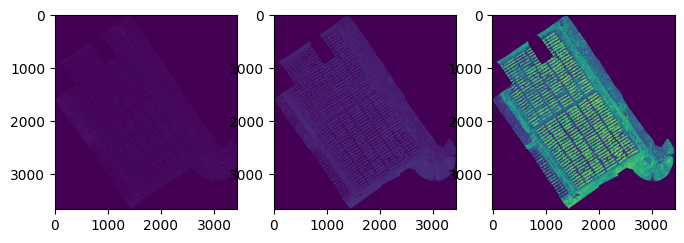

In [3]:
# Open the .hdr file (which automatically loads the .bsq data)
path_hdr_file = PathManager().get_abs_path_file('rionegro01_mosaic_geom_atm.hdr')
path_bsq_file = PathManager().get_abs_path_file('rionegro01_mosaic_geom_atm.bsq')

img = spectral.open_image(path_hdr_file)

# Access the wavelegths associated with each band
wavelegths = img.bands.centers

print('Shape of hyperspectral data:', img.shape)
print('Number of bands:', img.shape[2])
print('wavelegths:', wavelegths)

fig, ax = plt.subplots(1, 3, figsize=(8, 25))
ax = ax.flatten()

ind = wavelegths.index(463.36264)
ax[0].imshow(img[:, :, ind])

ind = wavelegths.index(559.30249)
ax[1].imshow(img[:, :, ind])

ind = wavelegths.index(745.36766)
ax[2].imshow(img[:, :, ind])

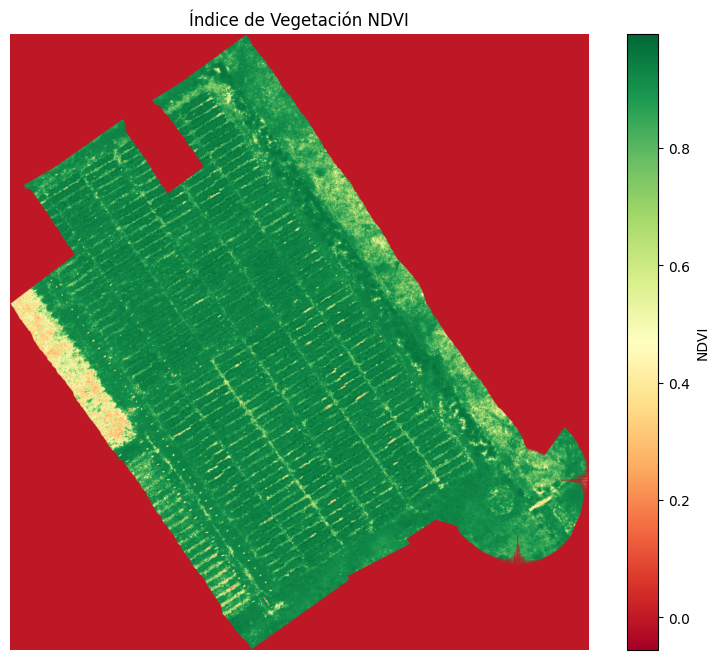

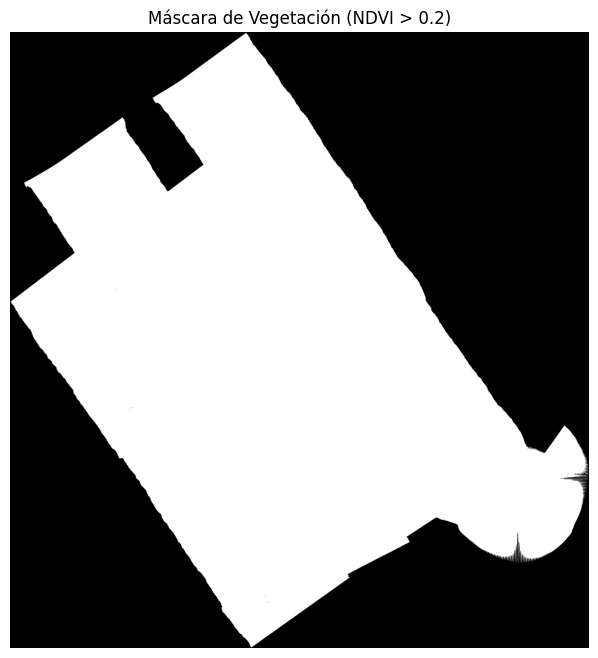

In [4]:
# === 2. SELECCIONAR BANDAS PARA NDVI ===
# Aquí debes identificar qué índice corresponde a cada longitud de onda.
# Esto depende de tu sensor. Usualmente:
# Banda Roja ~660 nm
# Banda NIR ~800 nm

# EJEMPLO: usa los índices reales según el .hdr
red_band_index = wavelegths.index(661.05688)   # Cambia esto si sabes el índice exacto para 660 nm
nir_band_index = wavelegths.index(800.60575)   # Cambia esto si sabes el índice exacto para 800 nm

red = img[:, :, red_band_index].astype(np.float32)
nir = img[:, :, nir_band_index].astype(np.float32)

# === 3. CALCULAR NDVI ===
ndvi = (nir - red) / (nir + red + 1e-10)  # +epsilon para evitar división por cero

# === 4. VISUALIZAR NDVI ===
plt.figure(figsize=(10, 8))
plt.imshow(ndvi, cmap='RdYlGn')
plt.colorbar(label='NDVI')
plt.title('Índice de Vegetación NDVI')
plt.axis('off')
plt.show()

# === 5. MÁSCARA DE VEGETACIÓN ===
# Umbral típico: > 0.2 indica vegetación
black_space_mask = ndvi > 0.1

# Visualizar máscara
plt.figure(figsize=(10, 8))
plt.imshow(black_space_mask, cmap='gray')
plt.title('Máscara de Vegetación (NDVI > 0.2)')
plt.axis('off')
plt.show()


In [42]:
img[:, :, 0:10][black_space_mask.squeeze()]

array([[0.0069, 0.0067, 0.0066, ..., 0.0046, 0.0046, 0.0045],
       [0.0061, 0.0059, 0.0058, ..., 0.0045, 0.0046, 0.0045],
       [0.0045, 0.0044, 0.0045, ..., 0.0049, 0.0046, 0.0042],
       ...,
       [0.0079, 0.0084, 0.009 , ..., 0.0114, 0.011 , 0.0108],
       [0.0096, 0.0098, 0.0096, ..., 0.0085, 0.0088, 0.0086],
       [0.0102, 0.0101, 0.0101, ..., 0.0095, 0.0096, 0.0095]],
      shape=(6171396, 10))

In [5]:
black_space_mask

array([[[False],
        [False],
        [False],
        ...,
        [False],
        [False],
        [False]],

       [[False],
        [False],
        [False],
        ...,
        [False],
        [False],
        [False]],

       [[False],
        [False],
        [False],
        ...,
        [False],
        [False],
        [False]],

       ...,

       [[False],
        [False],
        [False],
        ...,
        [False],
        [False],
        [False]],

       [[False],
        [False],
        [False],
        ...,
        [False],
        [False],
        [False]],

       [[False],
        [False],
        [False],
        ...,
        [False],
        [False],
        [False]]], shape=(3660, 3438, 1))

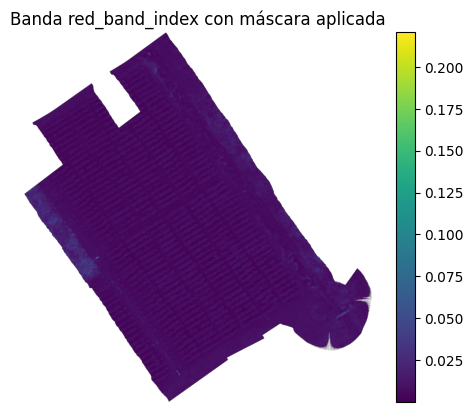

In [ ]:
banda = img[:, :, [nir_band_index, red_band_index]]  # Elige una banda representativa
masked_banda = np.where(black_space_mask, banda, np.nan)  # Aplica la máscara

plt.imshow(masked_banda, cmap='viridis')
plt.title('Banda red_band_index con máscara aplicada')
plt.axis('off')
plt.colorbar()
plt.show()



In [8]:
masked_banda

array([[[nan],
        [nan],
        [nan],
        ...,
        [nan],
        [nan],
        [nan]],

       [[nan],
        [nan],
        [nan],
        ...,
        [nan],
        [nan],
        [nan]],

       [[nan],
        [nan],
        [nan],
        ...,
        [nan],
        [nan],
        [nan]],

       ...,

       [[nan],
        [nan],
        [nan],
        ...,
        [nan],
        [nan],
        [nan]],

       [[nan],
        [nan],
        [nan],
        ...,
        [nan],
        [nan],
        [nan]],

       [[nan],
        [nan],
        [nan],
        ...,
        [nan],
        [nan],
        [nan]]], shape=(3660, 3438, 1))